# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Importing the Machine Learning models we require from Scikit-Learn

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# Importing the other functions we may require from Scikit-Learn
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


#pipeline
from sklearn.pipeline import Pipeline

# To get diferent metric scores
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,precision_recall_curve,roc_curve,make_scorer

# Code to ignore warnings from function usage
import warnings;
import numpy as np
warnings.filterwarnings('ignore')

In [2]:
#Load data
data=pd.read_csv("ExtraaLearn.csv")

## Data Preprocessing


In [ ]:
data.info()
#it seems that there is no missing data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


Most of the variables are categorical except  age, website_visits, page_views_per_visit and status.

In [ ]:
data.shape

(4612, 15)

In [ ]:
data.nunique()

,0
ID,4612
age,46
current_occupation,3
first_interaction,2
profile_completed,3
website_visits,27
time_spent_on_website,1623
page_views_per_visit,2414
last_activity,3
print_media_type1,2


I will drop the column ID as it is unique for each customer and will not add value to the model.

In [19]:
data.drop('ID',axis=1,inplace=True)


In [20]:
data_cat=data.drop(columns=['age', 'website_visits', 'page_views_per_visit','status','time_spent_on_website'])

In [21]:
data_cat

,current_occupation,first_interaction,profile_completed,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral
0,Unemployed,Website,High,Website Activity,Yes,No,Yes,No,No
1,Professional,Mobile App,Medium,Website Activity,No,No,No,Yes,No
2,Professional,Website,Medium,Website Activity,No,No,Yes,No,No
3,Unemployed,Website,High,Website Activity,No,No,No,No,No
4,Student,Website,High,Email Activity,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...
4607,Unemployed,Mobile App,Medium,Phone Activity,No,No,No,Yes,No
4608,Professional,Mobile App,Medium,Email Activity,No,No,No,No,No
4609,Professional,Website,High,Email Activity,No,No,No,No,No
4610,Professional,Mobile App,Medium,Website Activity,Yes,No,No,No,No


In [22]:
for column in data_cat:
  print(data_cat[column].value_counts())

current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
print_media_type2
No     4379
Yes     233
Name: count, dtype: int64
digital_media
No     4085
Yes     527
Name: count, dtype: int64
educational_channels
No     3907
Yes     705
Name: count, dtype: int64
referral
No     4519
Yes      93
Name: count, dtype: int64


## EDA

- It is a good idea to explore the data once again after manipulating it.

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    4612 non-null   int64  
 1   current_occupation     4612 non-null   object 
 2   first_interaction      4612 non-null   object 
 3   profile_completed      4612 non-null   object 
 4   website_visits         4612 non-null   int64  
 5   time_spent_on_website  4612 non-null   int64  
 6   page_views_per_visit   4612 non-null   float64
 7   last_activity          4612 non-null   object 
 8   print_media_type1      4612 non-null   object 
 9   print_media_type2      4612 non-null   object 
 10  digital_media          4612 non-null   object 
 11  educational_channels   4612 non-null   object 
 12  referral               4612 non-null   object 
 13  status                 4612 non-null   int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 504.6+ 

**Univariate analysis**

Below I will plot the histplots/boxplots and check whether there are outliers in the numerical data

In [24]:
# Defining the hist_box() function
def hist_box(data, col):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize=(12, 6))
    # Adding a graph in each part
    sns.boxplot(data=data, x=col, ax=ax_box, showmeans=True)
    sns.histplot(data=data, x=col, kde=True, ax=ax_hist)
    plt.show()

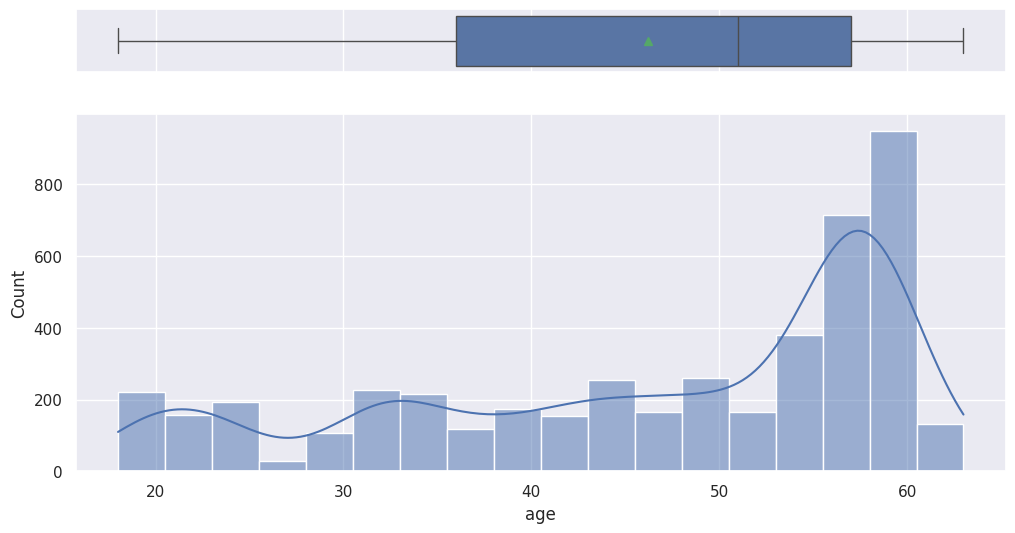

In [25]:
## Age

hist_box(data,'age')

Age distribution is left skewed - peakes at 59 years

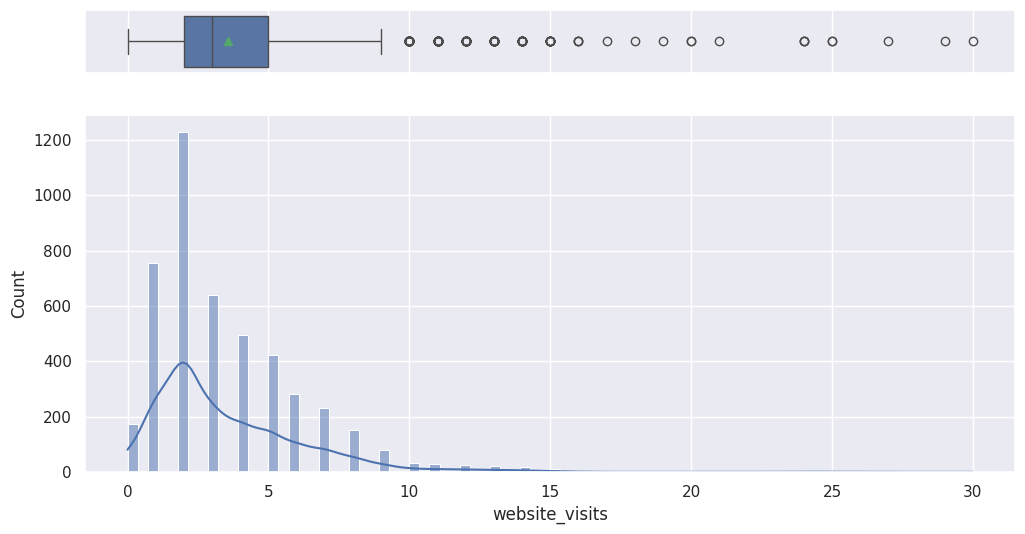

In [26]:
hist_box(data,'website_visits')

The website visits distribution is right skewed showing a peak at 2.

In [88]:
data=data[data['website_visits']<15]

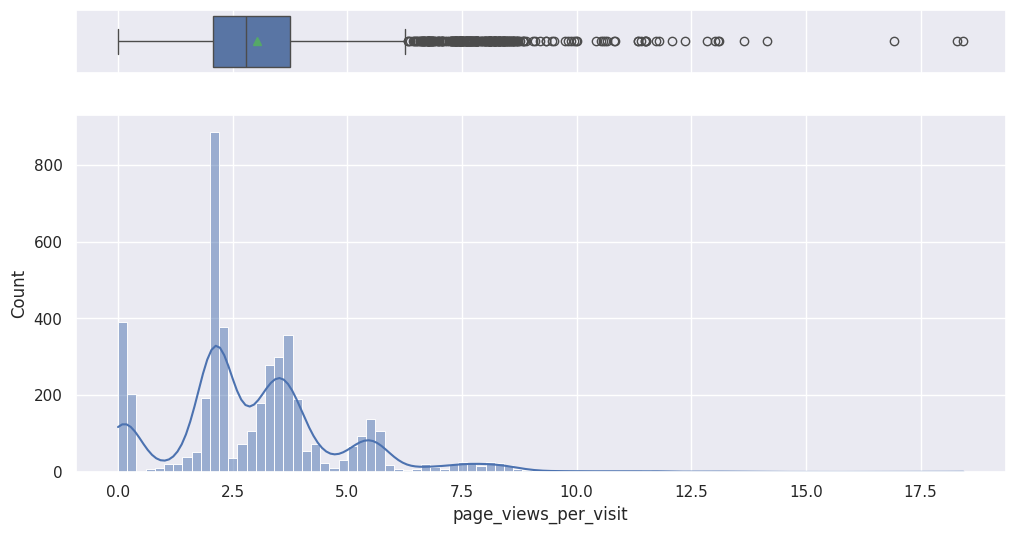

In [28]:
hist_box(data,'page_views_per_visit')

There are outliers for page views per visit when they exceed 10.


In [89]:
data=data[data['page_views_per_visit']<10]

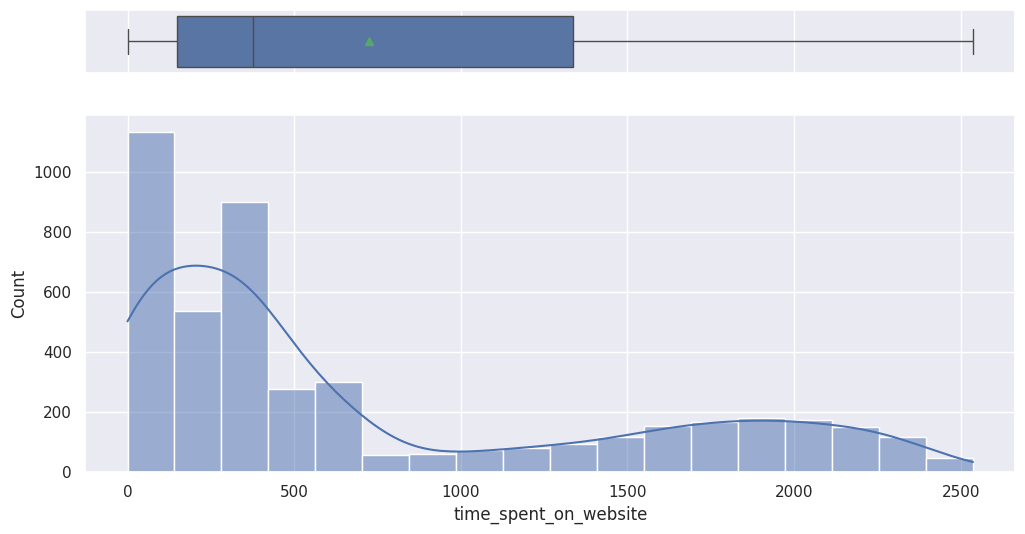

In [30]:
hist_box(data,'time_spent_on_website')

 Analyzing the categorical variables present in the data

In [31]:
data_cat.columns

Index(['current_occupation', 'first_interaction', 'profile_completed',
       'last_activity', 'print_media_type1', 'print_media_type2',
       'digital_media', 'educational_channels', 'referral'],
      dtype='object')

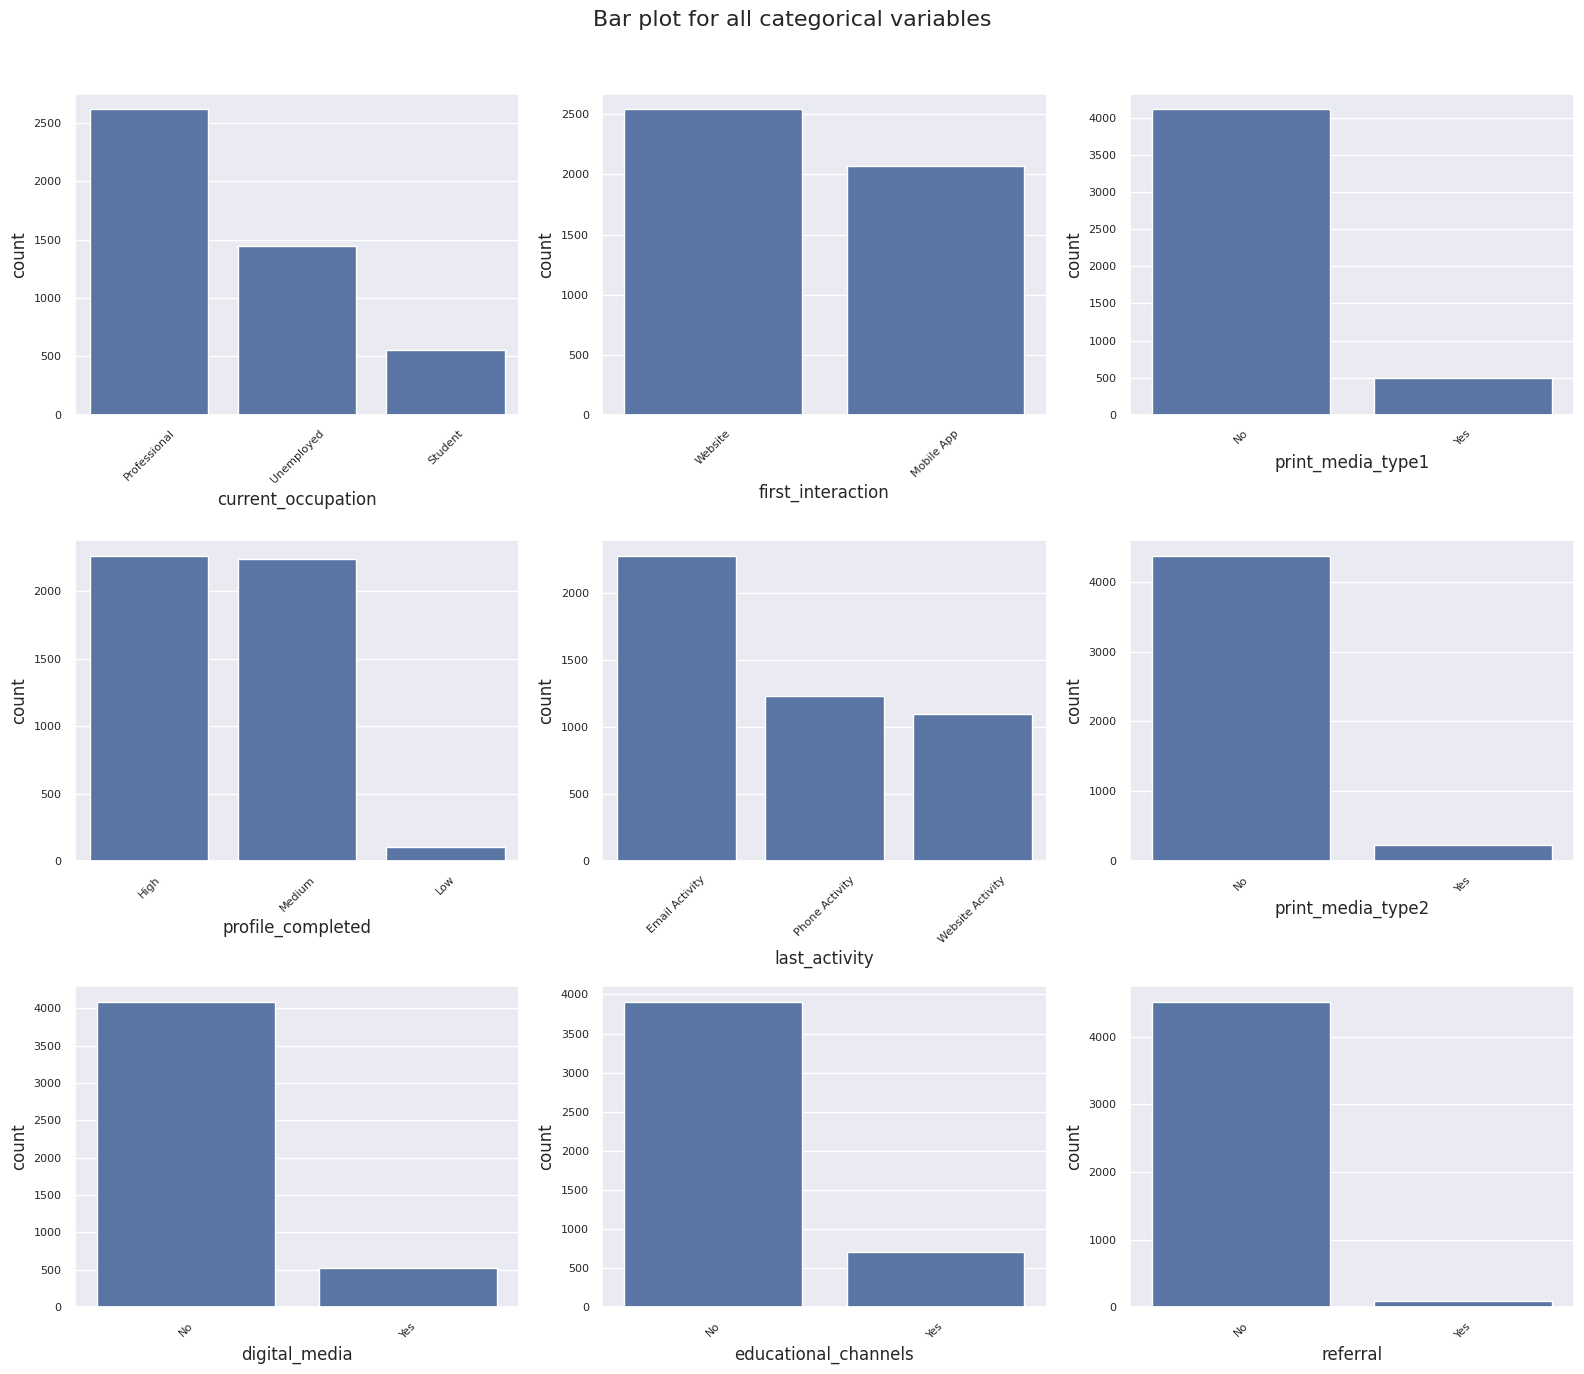

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

fig.suptitle('Bar plot for all categorical variables', fontsize=16)

sns.countplot(ax=axes[0, 0], x='current_occupation', data=data,
              order=data['current_occupation'].value_counts().index)

sns.countplot(ax=axes[0, 1], x='first_interaction', data=data,
              order=data['first_interaction'].value_counts().index)

sns.countplot(ax=axes[0, 2], x='print_media_type1', data=data,
              order=data['print_media_type1'].value_counts().index)

sns.countplot(ax=axes[1, 0], x='profile_completed', data=data,
              order=data['profile_completed'].value_counts().index)

sns.countplot(ax=axes[1, 1], x='last_activity', data=data,
              order=data['last_activity'].value_counts().index)

sns.countplot(ax=axes[1, 2], x='print_media_type2', data=data,
              order=data['print_media_type2'].value_counts().index)

sns.countplot(ax=axes[2, 0], x='digital_media', data=data,
              order=data['digital_media'].value_counts().index)

sns.countplot(ax=axes[2, 1], x='educational_channels', data=data,
              order=data['educational_channels'].value_counts().index)

sns.countplot(ax=axes[2, 2], x='referral', data=data,
              order=data['referral'].value_counts().index)

# formatting loop
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.subplots_adjust(hspace=0.6, wspace=0.4)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

**Bivariate analysis**

In [33]:

features=['age', 'website_visits', 'page_views_per_visit','time_spent_on_website']

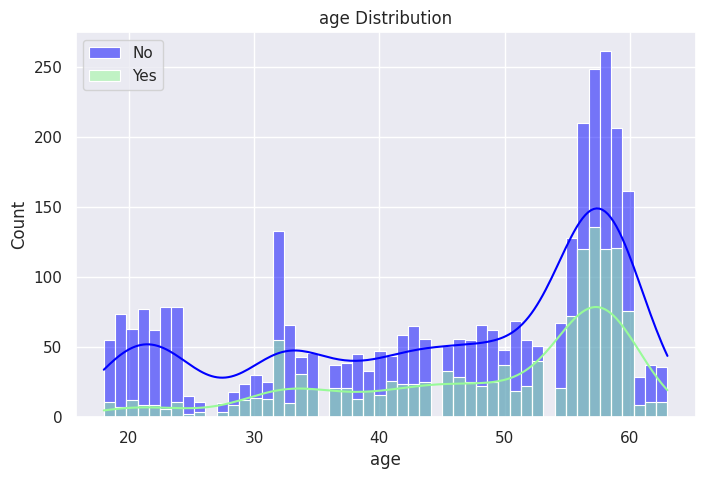

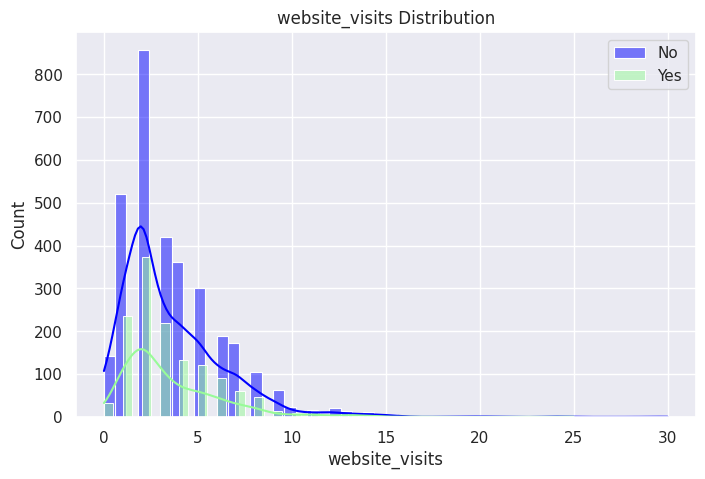

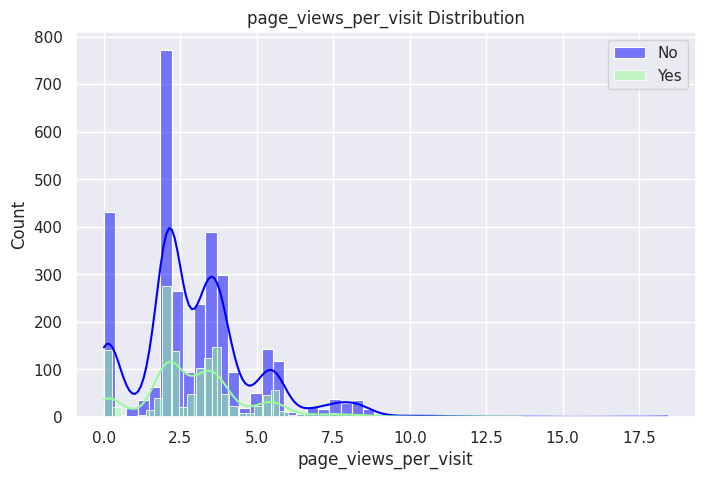

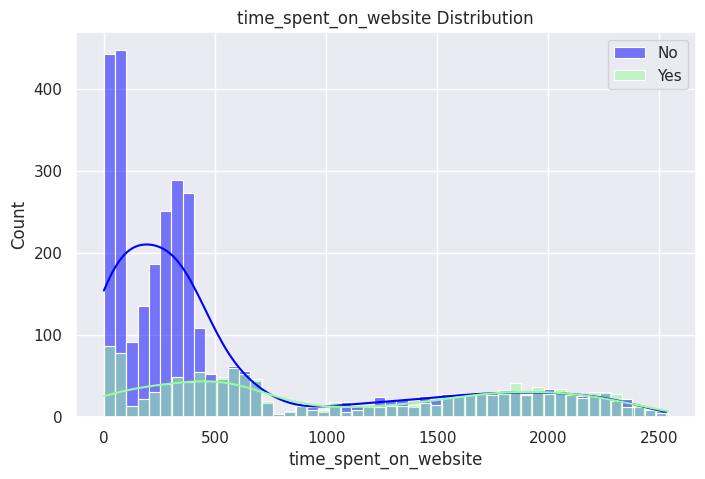

In [34]:
for feature in features:
    plt.figure(figsize=(8,5))

    sns.histplot(data[data['status'] == 0][feature],
                 color='blue', label='No', bins=50, kde=True)

    sns.histplot(data[data['status'] == 1][feature],
                 color='palegreen', label='Yes', bins=50, kde=True)
    plt.savefig('q7.png')
    plt.title(f'{feature} Distribution')
    plt.legend()
    plt.show()

The Yes distribution overlaps No distribution. Even though the No choice has more counts it is not clearly distinguishable that these three parameters play a significant role in determinng status.
The only parameter that shows a differance is time_spent. Most of those who have not been customers send less time on websides while those you are customers spend small and big amount of time.

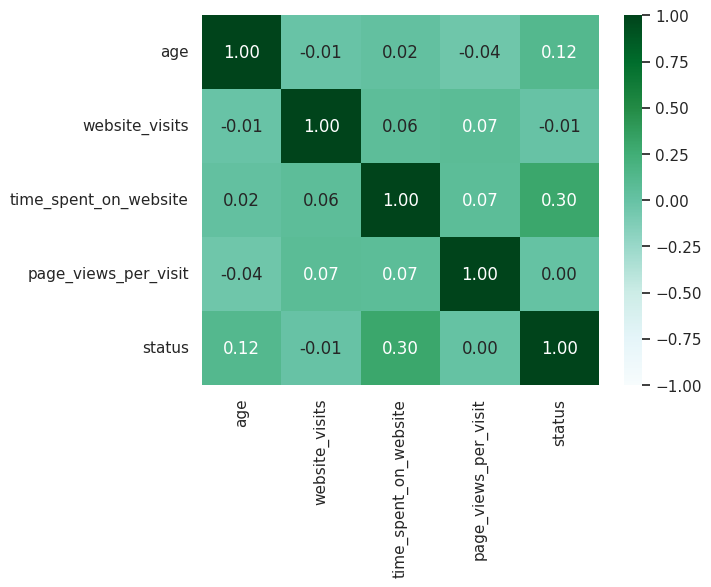

In [35]:
#For the numerical values - Heatmap

cols_list = data.select_dtypes(include=np.number).columns.tolist()

sns.heatmap(data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="BuGn")
plt.show()

    No significant anticorrelation
    Possitive correlation status vr
  
    1. time_spent_on_website
    2. age
    3. page_views_per_visits
    4. webside visits

In [36]:
# Defining the stacked_barplot() function
def stacked_barplot(data,predictor,target,figsize=(10,6)):
  (pd.crosstab(data[predictor],data[target],normalize='index')*100).plot(kind='bar',figsize=figsize,stacked=True)
  plt.legend(loc="lower right")
  plt.ylabel(target)

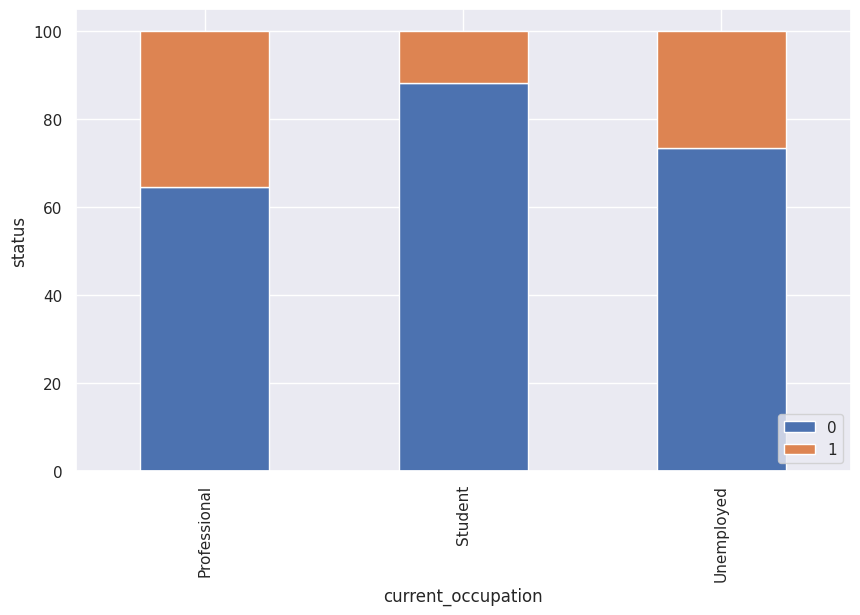

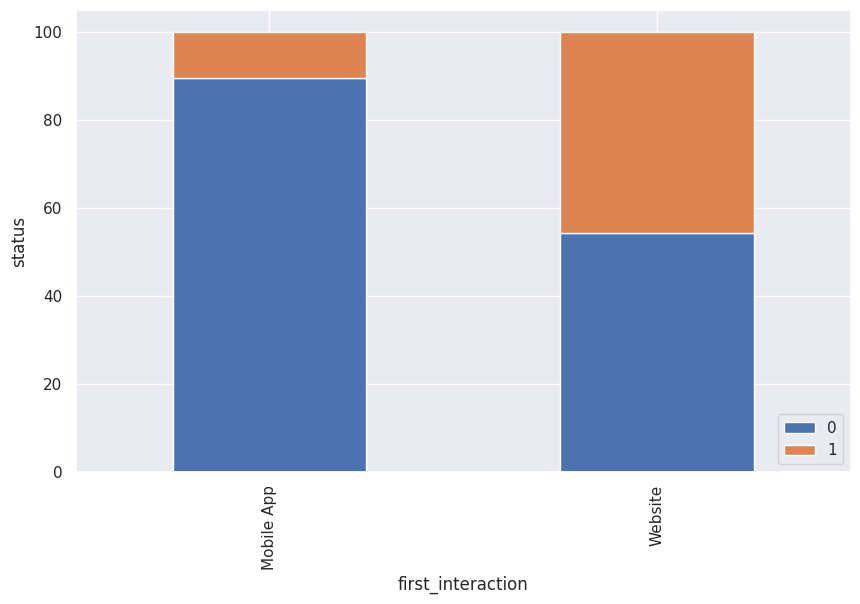

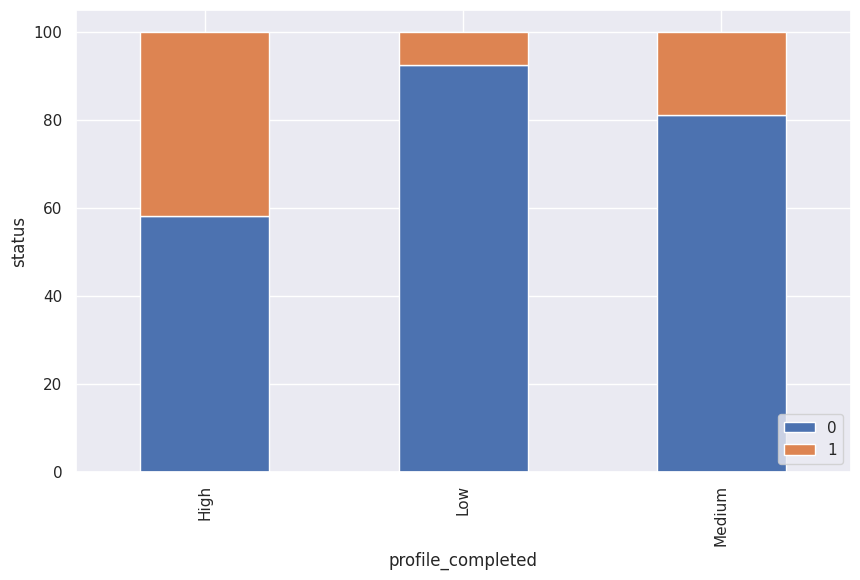

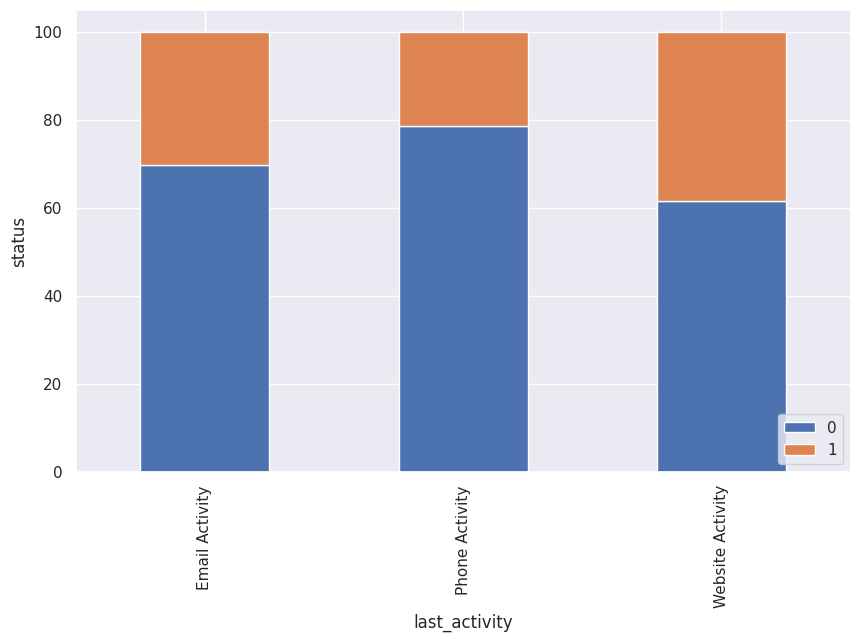

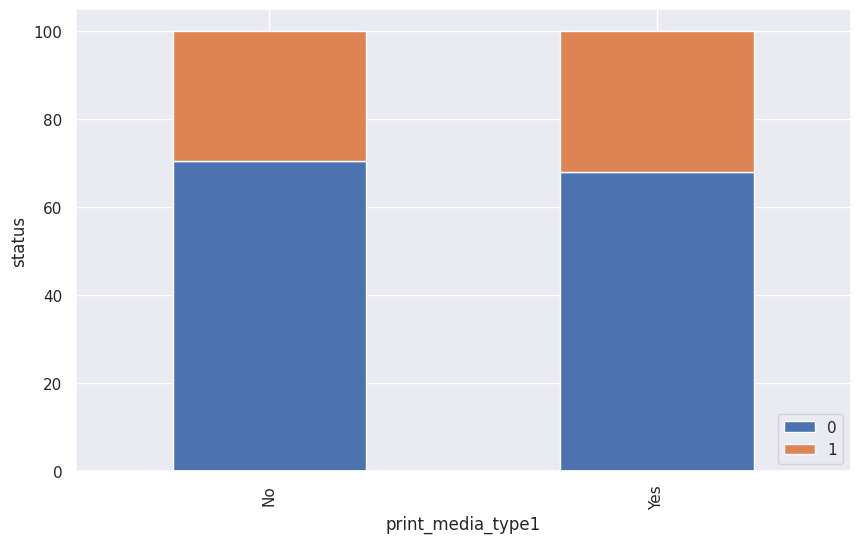

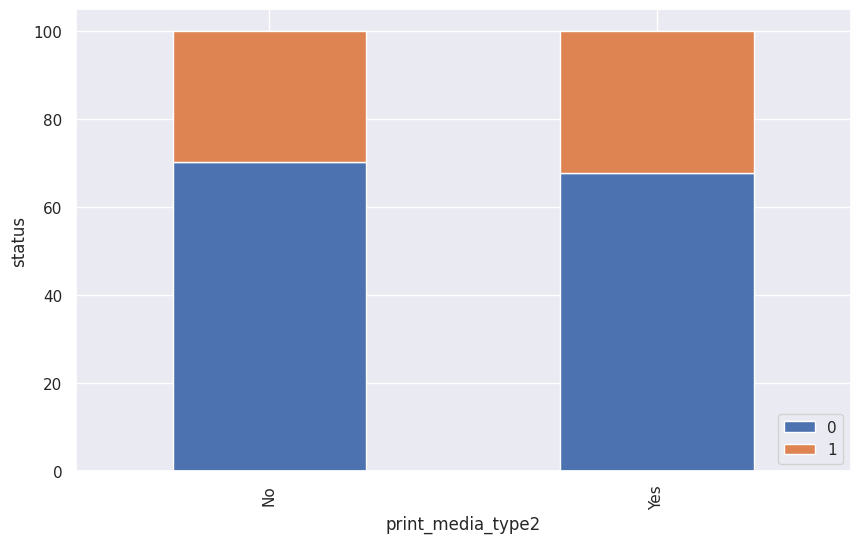

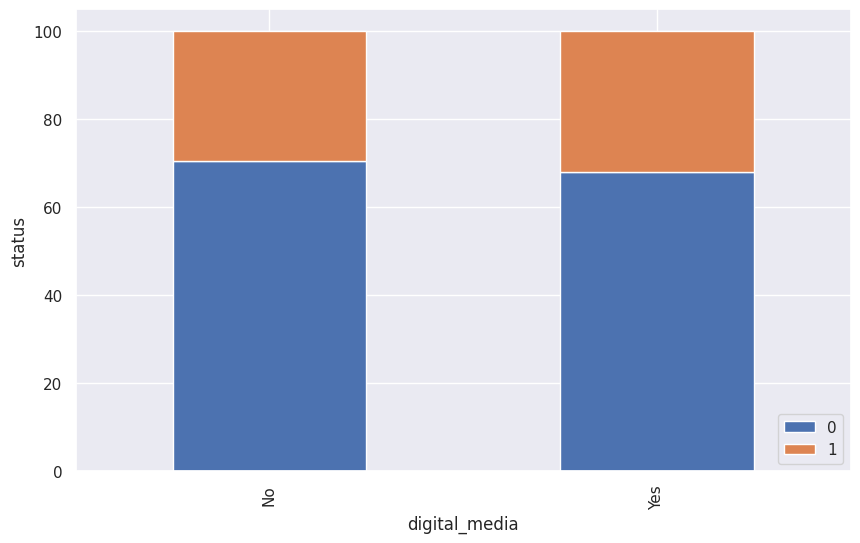

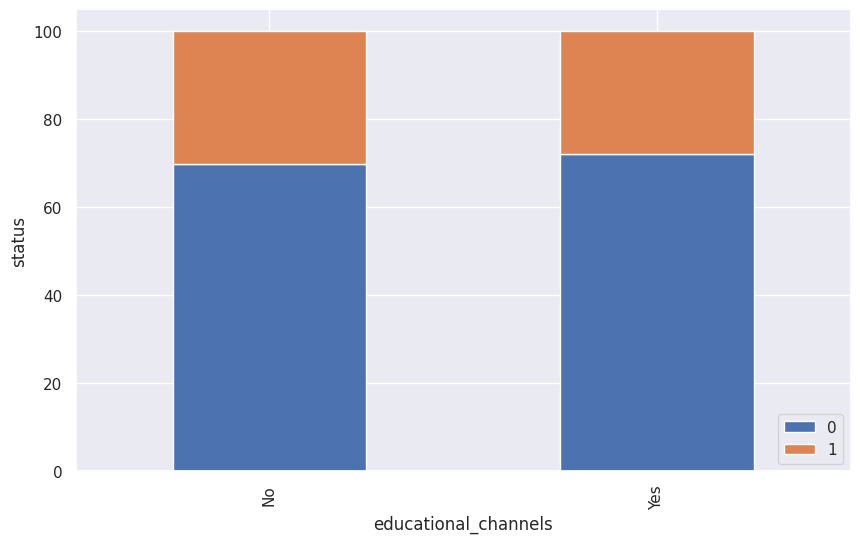

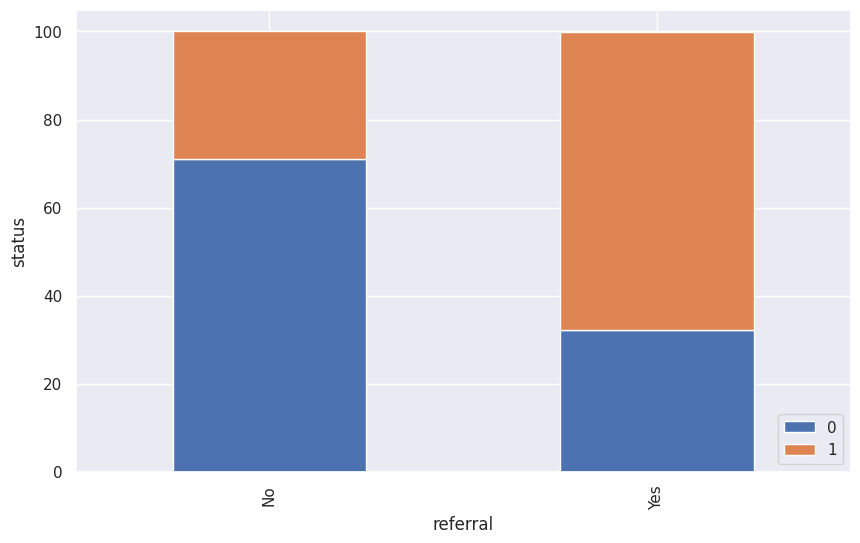

In [37]:
for c in data_cat:
  stacked_barplot(data,c,'status')

## Building a Decision Tree model

In [38]:
data.columns

Index(['age', 'current_occupation', 'first_interaction', 'profile_completed',
       'website_visits', 'time_spent_on_website', 'page_views_per_visit',
       'last_activity', 'print_media_type1', 'print_media_type2',
       'digital_media', 'educational_channels', 'referral', 'status'],
      dtype='object')

In [39]:
X=data.drop(['status','last_activity', 'print_media_type1',
       'print_media_type2', 'digital_media', 'educational_channels','website_visits'],axis=1)

y=data['status']



In [40]:
y.value_counts()


,count
status,
0,3235
1,1377


The dataset is moderately imbalanced.

In [90]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

Some classification problems can exhibit a large imbalance in the distribution of the target classes: for instance there could be several times more negative samples than positive samples. In such cases it is recommended to use the stratified sampling technique to ensure that relative class frequencies are approximately preserved in each train and validation fold.

In [91]:
#Encoding categorical data

#List of columns to create a dummy variables
col_dummy=['current_occupation', 'first_interaction', 'profile_completed',
      'referral']
#Encoding categorical varaibles
X_train=pd.get_dummies(X_train, columns=col_dummy, drop_first=True)
X_test=pd.get_dummies(X_test, columns=col_dummy, drop_first=True)

In [92]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [93]:
model= DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [94]:
# Creating metric function
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))

    sns.heatmap(cm, annot=True,  fmt='.2f')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [95]:
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       1.00      1.00      1.00       964

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



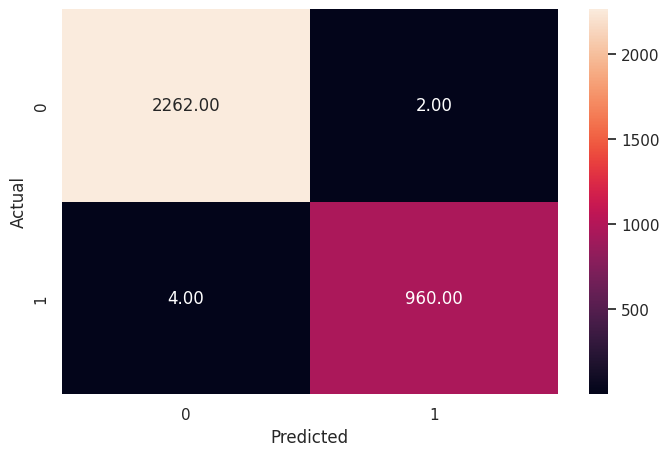

In [96]:
metrics_score(y_train,y_pred_train)

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       971
           1       0.64      0.65      0.65       413

    accuracy                           0.79      1384
   macro avg       0.75      0.75      0.75      1384
weighted avg       0.79      0.79      0.79      1384



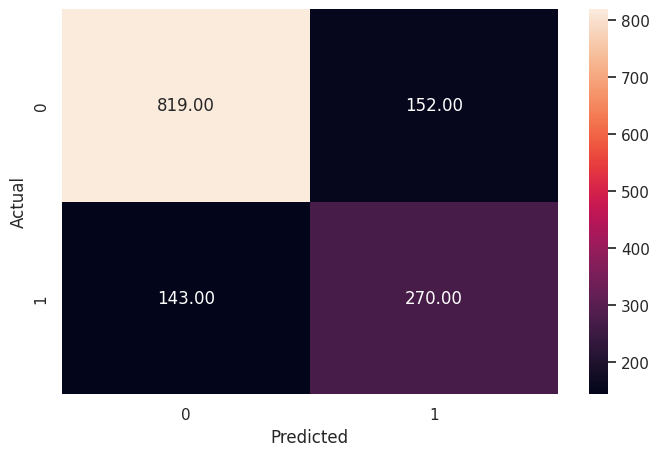

In [97]:
metrics_score(y_test,y_pred_test)

Almost 0 errors on the training set, each sample has been classified correctly.
Model has performed very well on the training set. However the model has much lower accuracy on test data. Therefore the decision tree model is clearly overfitting. I will have to tune the decision tree to reduce the overfitting

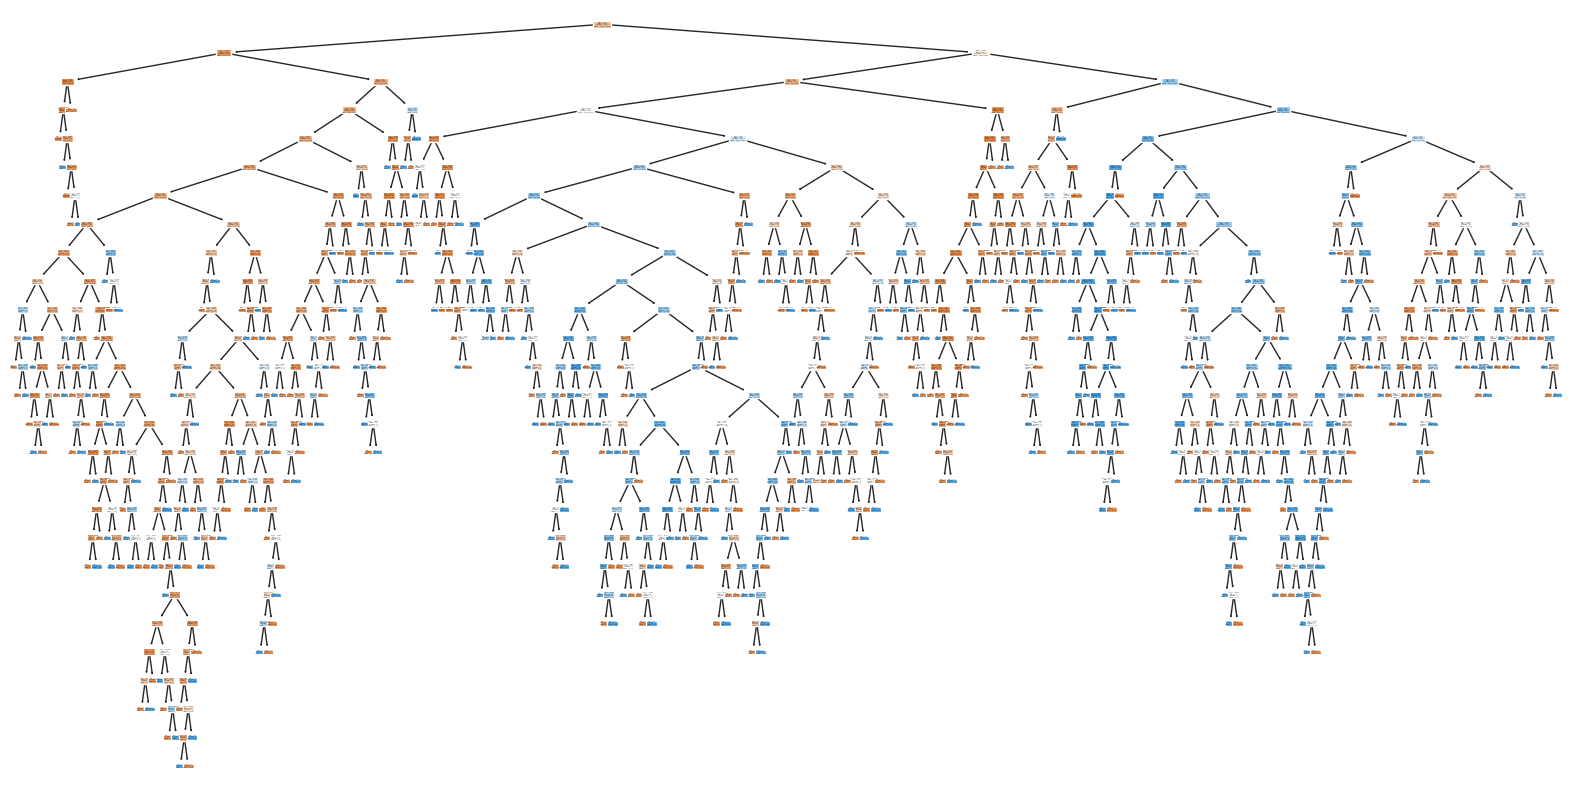

In [ ]:
plt.figure(figsize=(20, 10))
tree.plot_tree(model,filled=True)
plt.show()

In [49]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

In [50]:
model.get_depth(),model.get_n_leaves()

(24, np.int64(528))

Perform hyperparameter tuning for the decision tree model using GridSearch CV

In [98]:
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_depth": np.arange(1,100,10),
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}
# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, cv=5,scoring='recall',n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(11), max_leaf_nodes=50,
                       min_samples_split=10, random_state=1)

So  we need to prune the tree, the depth from 24 should go to 11 and max_leaf_nodes from 528 to 50

Rerun the decission tree code for the best hyperparameters

In [100]:
yptr=estimator.predict(X_train)
ypts=estimator.predict(X_test)



              precision    recall  f1-score   support

           0       0.90      0.93      0.91      2264
           1       0.81      0.75      0.78       964

    accuracy                           0.87      3228
   macro avg       0.85      0.84      0.85      3228
weighted avg       0.87      0.87      0.87      3228



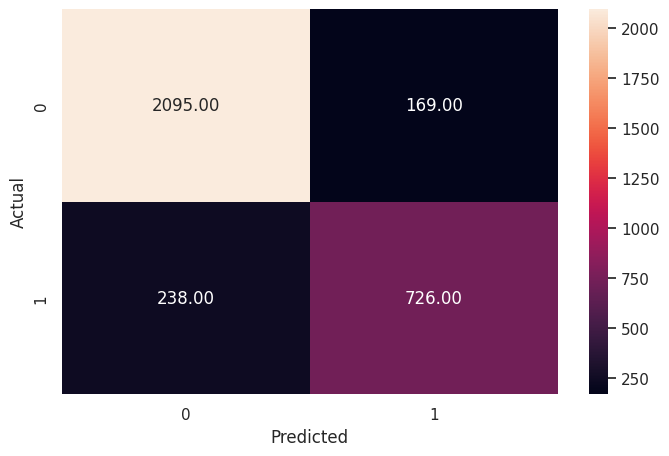

In [101]:
metrics_score(y_train,yptr)

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       971
           1       0.75      0.72      0.73       413

    accuracy                           0.84      1384
   macro avg       0.82      0.81      0.81      1384
weighted avg       0.84      0.84      0.84      1384



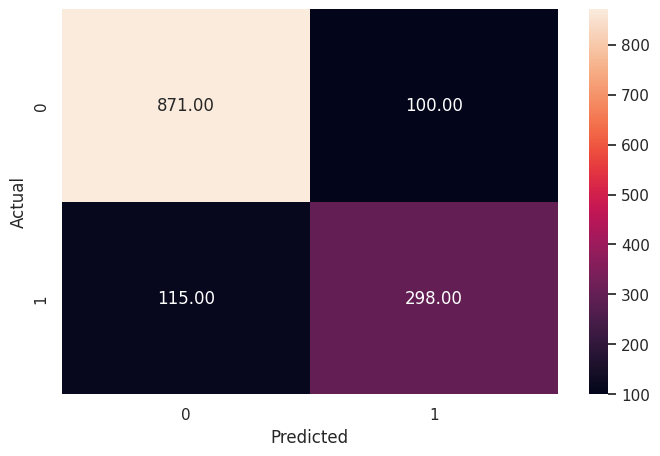

In [102]:
metrics_score(y_test,ypts)

Better result but the model is still overfitting

## Building a Random Forest model

In [103]:
#rerun the train test split and encoding blocks above
rf = RandomForestClassifier( random_state = 1)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       0.99      1.00      1.00       964

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



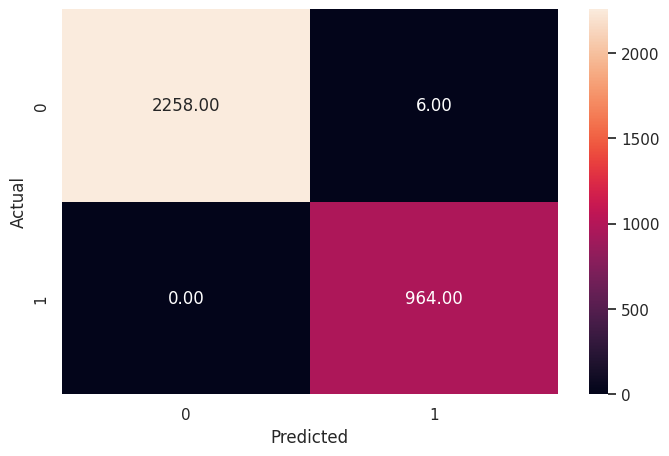

In [104]:
y_pred_train_rf = rf.predict(X_train)

metrics_score(y_train, y_pred_train_rf)

              precision    recall  f1-score   support

           0       0.87      0.88      0.87       971
           1       0.71      0.70      0.70       413

    accuracy                           0.82      1384
   macro avg       0.79      0.79      0.79      1384
weighted avg       0.82      0.82      0.82      1384



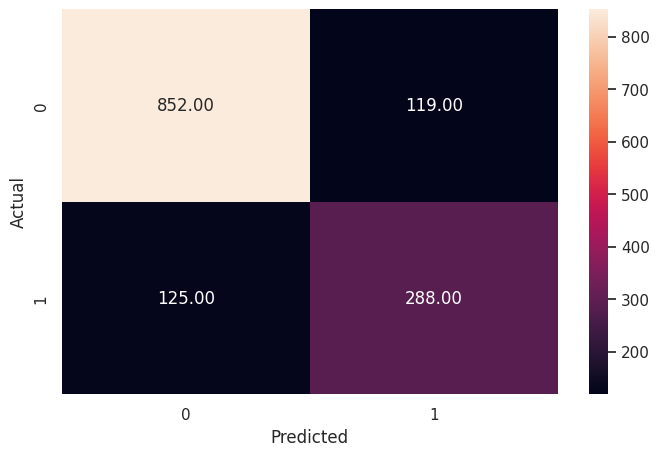

In [105]:
y_pred_test_rf = rf.predict(X_test)

metrics_score(y_test, y_pred_test_rf)

The random forest classifier seems to be overfitting since the metrics of the training and the testing datasets differ a lot. The precission and recall are the same as above in the case after hyperparameter tuning and the accuracy is slightly lower.

In [106]:


params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [107]:
best_rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=200,
                       random_state=1)

In [108]:
#in the first random forest case
depths = [tree.get_depth() for tree in rf.estimators_]
leaves = [tree.get_n_leaves() for tree in rf.estimators_]

print("Average depth:", sum(depths)/len(depths))
print("Average leaves:", sum(leaves)/len(leaves))

Average depth: 23.17
Average leaves: 464.51


In [109]:
rf_final = RandomForestClassifier(
    max_depth=10,
    min_samples_split=10,
    n_estimators=200,
    max_features='sqrt',
    random_state=1,
    class_weight='balanced',
    min_samples_leaf=5,

)

rf_final.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=1)

In [110]:
y_pred = rf_final.predict(X_test)
y_pred_tr=rf_final.predict(X_train)

              precision    recall  f1-score   support

           0       0.95      0.88      0.91      2264
           1       0.76      0.89      0.82       964

    accuracy                           0.88      3228
   macro avg       0.85      0.88      0.86      3228
weighted avg       0.89      0.88      0.88      3228



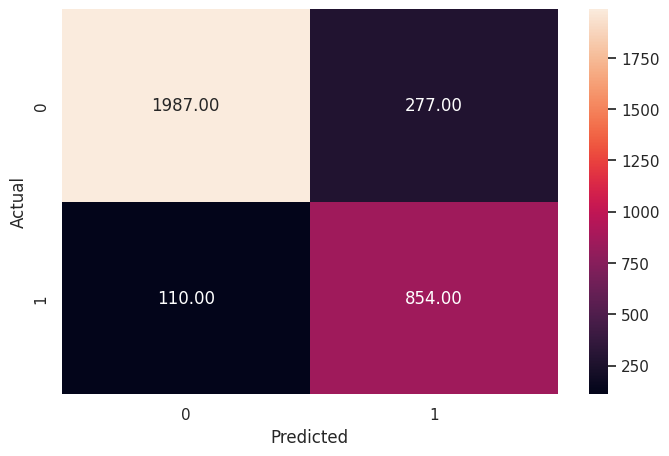

In [111]:
metrics_score(y_train,y_pred_tr)


              precision    recall  f1-score   support

           0       0.85      0.84      0.85       971
           1       0.64      0.65      0.65       413

    accuracy                           0.79      1384
   macro avg       0.75      0.75      0.75      1384
weighted avg       0.79      0.79      0.79      1384



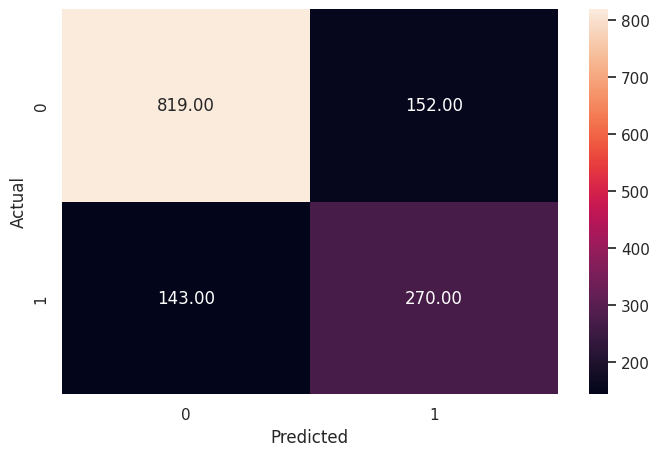

In [112]:
metrics_score(y_test,y_pred_test)

A Random Forest classifier was trained using hyperparameter tuning with GridSearchCV. The model was optimized using recall as the scoring metric to prioritize identifying potential customers. Compared to the Decision Tree model, the Random Forest demonstrated improved generalization and reduced overfitting due to its ensemble nature.

Balancing class methods

SMOTE

In [113]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=1)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [114]:
print(y_train_smote.value_counts())

status
1    2264
0    2264
Name: count, dtype: int64


In [115]:
rf_smote = RandomForestClassifierrf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    random_state=1
)

rf_smote.fit(X_train_smote, y_train_smote)
y_pred=rf_smote.predict(X_train)
y_pred_test = rf_smote.predict(X_test)

              precision    recall  f1-score   support

           0       0.91      0.84      0.88      2264
           1       0.69      0.82      0.75       964

    accuracy                           0.84      3228
   macro avg       0.80      0.83      0.81      3228
weighted avg       0.85      0.84      0.84      3228



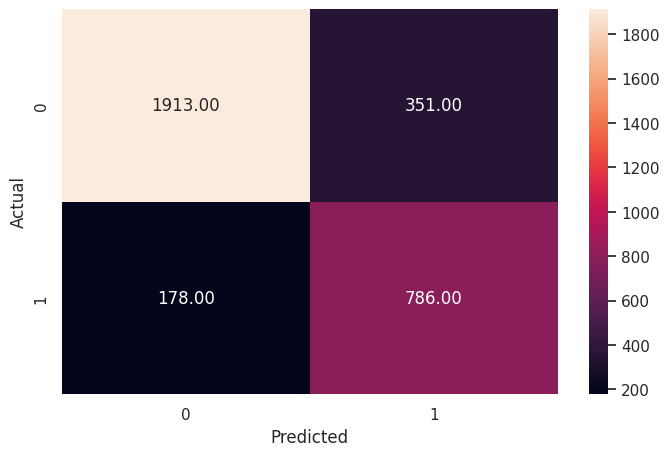

In [116]:
metrics_score(y_train,y_pred)

              precision    recall  f1-score   support

           0       0.91      0.84      0.88       971
           1       0.69      0.80      0.74       413

    accuracy                           0.83      1384
   macro avg       0.80      0.82      0.81      1384
weighted avg       0.84      0.83      0.84      1384



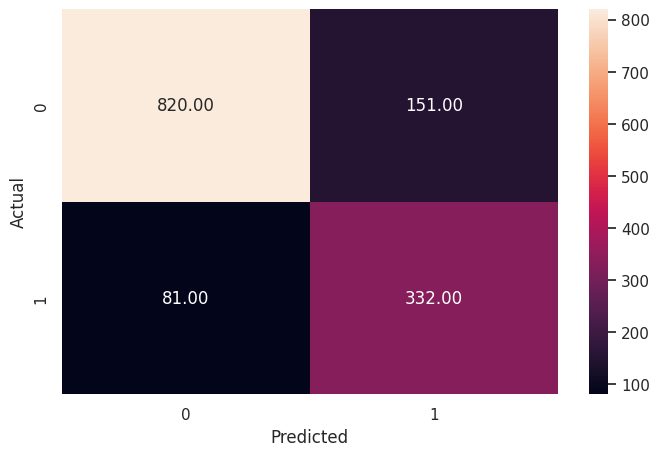

In [117]:
metrics_score(y_test,y_pred_test)

The current Random Forest:

handles imbalance well
predicts minority class effectively
has stable generalization
achieves good recall
avoids severe overfitting

This is a solid classification model.

In [118]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, y_prob))

0.8923515608830417


The Random Forest classifier achieved an ROC-AUC score of 0.892, indicating strong discriminative ability between the two classes. This suggests that the model is highly effective at distinguishing positive and negative outcomes across different classification thresholds.

In [119]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(10))

                         Feature  Importance
1          time_spent_on_website    0.338400
2           page_views_per_visit    0.189397
5      first_interaction_Website    0.178635
0                            age    0.136966
7       profile_completed_Medium    0.090360
4  current_occupation_Unemployed    0.027232
3     current_occupation_Student    0.014351
6          profile_completed_Low    0.013849
8                   referral_Yes    0.010811


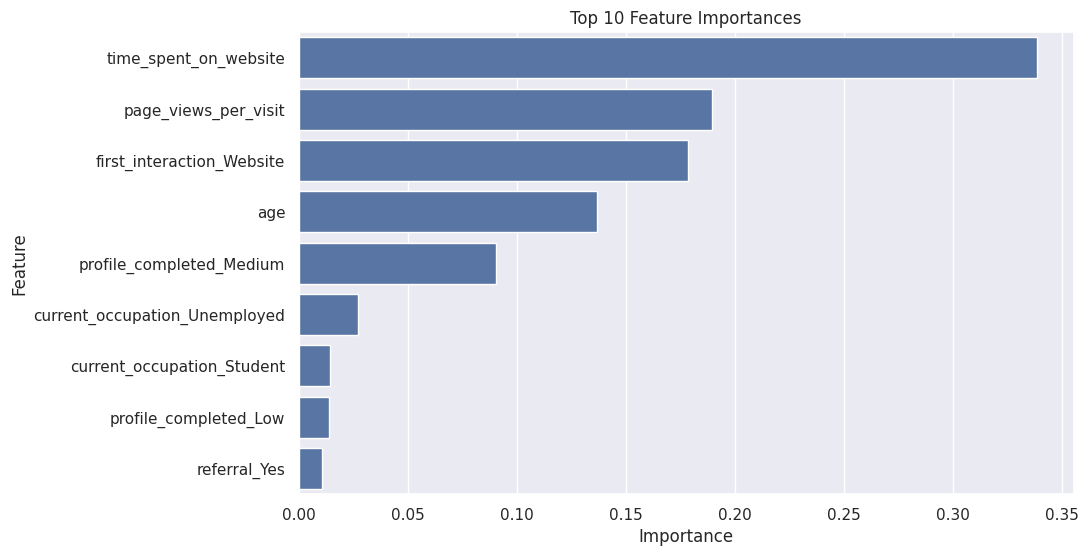

In [120]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Feature Importances")
plt.show()

## Actionable Insights and Recommendations

In this project, both a Decision Tree and a Random Forest classifier were implemented to predict whether a lead would convert into a potential customer. The initial Decision Tree model produced a deep and complex structure, indicating a high risk of overfitting. This was confirmed by the large tree depth and high number of leaf nodes.

To improve generalization, hyperparameter tuning was performed using GridSearchCV, resulting in a pruned Decision Tree with reduced complexity and improved predictive stability. However, due to the inherent limitations of a single decision tree, a Random Forest classifier was also implemented.

The Random Forest model, optimized using cross-validation and recall as the primary scoring metric, demonstrated superior performance and stability. Since the dataset exhibited moderate class imbalance, balancing techniques were applied to improve the prediction of the minority class. This significantly improved recall and F1-score for converted leads.

Additional regularization reduced overfitting substantially, as training and testing performance became closely aligned, indicating strong generalization capability.

The final Random Forest model achieved:

Accuracy: 83%
Recall: 80%
F1-score: 74%
ROC-AUC: 0.892

Feature importance analysis revealed that variables related to user engagement, particularly time spent on the website and page views per visit, were the most influential predictors of lead conversion.

Overall, the Random Forest model outperformed the Decision Tree and is the preferred model for this problem, as it provides a better balance between predictive accuracy, recall, and generalization while effectively identifying potential customers.